In [1]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.optimize import nnls
import os
import re
import random

import importlib
import cleaning as clean

---
New notebook post data cleaning.

In [2]:
data_path = os.path.abspath("../data/tcga_data2.csv")
raw_df = pd.read_csv(data_path, sep = '\t', low_memory = False)
raw_df.head(1)

,Gene,Study of Origin,Sample ID,Cancer Type,Cancer Type Detailed,Protein Change,Annotation,Custom Driver,Custom Driver Tiers,Functional Impact,...,Tumor Type,Used in Genomic Analysis,Vascular invasion indicator,Vessel Invasion,Vial number,Patient's Vital Status,Patient Weight,WGD,Winter Hypoxia Score,Year of Diagnosis
0,APC,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",TCGA-AA-A010-01,Colorectal Cancer,Colon Adenocarcinoma,A2D,"OncoKB: Unknown, level NA, resistance NA;reVUE...",NaN,NaN,MutationAssessor: NA;SIFT: impact: deleterious...,...,NaN,NaN,NO,NaN,A,NaN,NaN,NaN,NaN,NaN


In [3]:
relevant = ["Gene", "Sample ID", "Cancer Type Detailed", "Mutation Type", "Variant Type", "HGVSc", "MS", 
        "Protein Change", "Functional Impact"]
clean_df = clean.clean_data(raw_df,
                relevant_cols = relevant, early_age = 50)
clean_df.head(1)

,Gene,Sample ID,Cancer Type Detailed,Mutation Type,Variant Type,HGVSc,MS,Protein Change,Functional Impact,Age,Early Onset
0,APC,TCGA-AA-A010-01,Colon Adenocarcinoma,Missense_Mutation,SNP,ENST00000257430.4:c.5C>A,Somatic,A2D,MutationAssessor: NA;SIFT: impact: deleterious...,46.0,True


---
---
---

All signature information is `GRCh38`.

In [4]:
# Note that the Context labels are not in the same order as in the Webpage.
data_path_signatures = os.path.abspath("../data/Context_SBS_2.txt")
sig_df = pd.read_csv(data_path_signatures, sep = ",")

sig_df.head(1)

,Context,SBS88_GRCh38,SBS1_GRCh38,SBS5_GRCh38,SBS18_GRCh38
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534


Liang/Adele's notebook does the following cleaning/prep on the signatures.
1. Add a `Normal_colon` signature profile as $0.4*SBS1 + 0.4*SBS5 + 0.2*SBS18$.
1. Reorder the data so that the basis change is first (match the web graphics).

Put those together in `cleaning.py`'s `clean_sigs()`. Added a `Mutation` column just for colouring the bar charts (below).

In [5]:
importlib.reload(clean)
clean_sig_df = clean.clean_sigs(sig_df)
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A


In [6]:
def threshold(df, alpha = 0.025):
    ''' 
    Threshold mutational signatures to only include those with p > alpha.
    NOTE Dataframe only has "Context" and one other column.
    '''

    cols = [col for col in df.columns if ('SBS' in col) or ("Normal" in col)]
    if (len(cols) > 1):
        # Could raise value error instead.
        print(f'WARN: Only thresholding the first column {cols[0]}.')

    col = cols[0]
    thresholded = df[df[col] > alpha]

    return thresholded

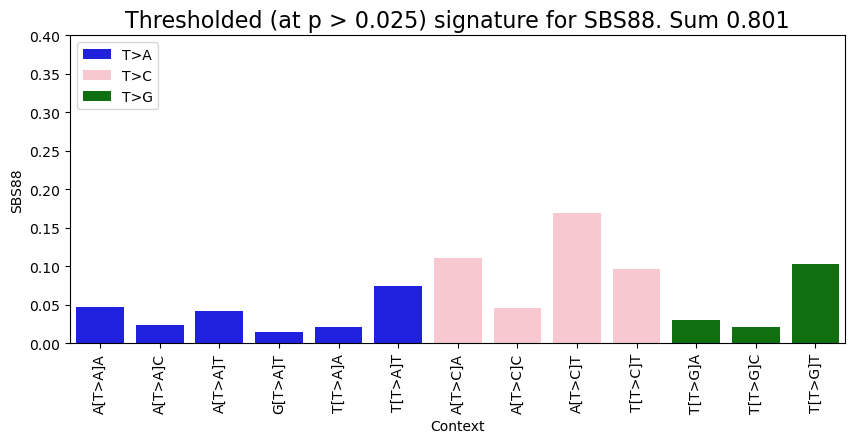

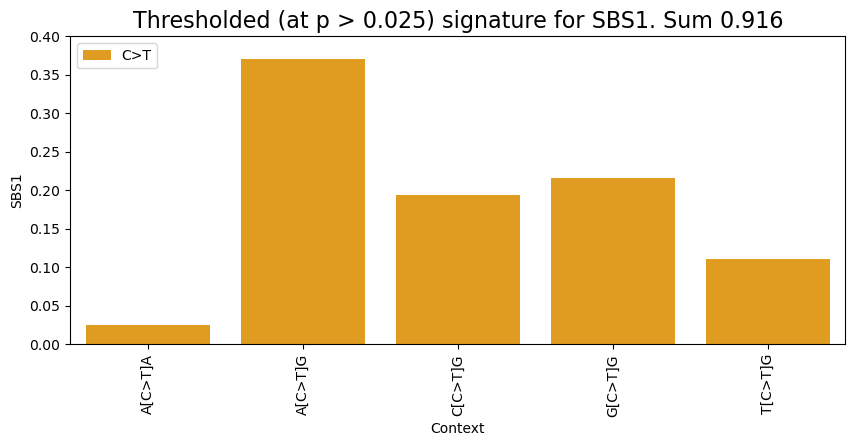

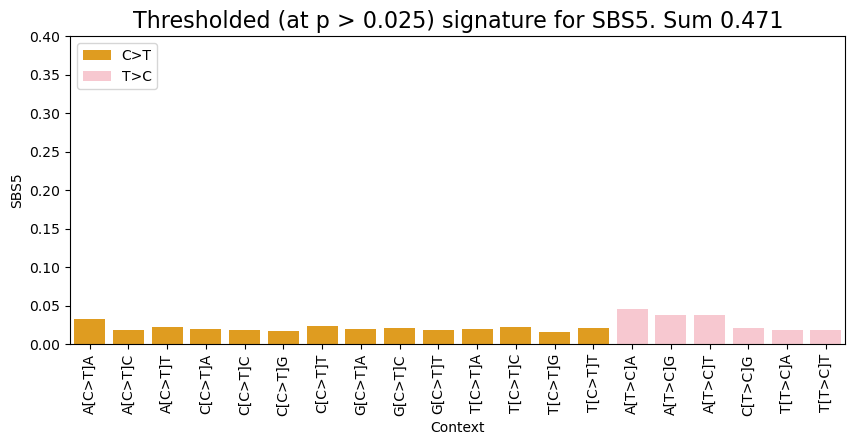

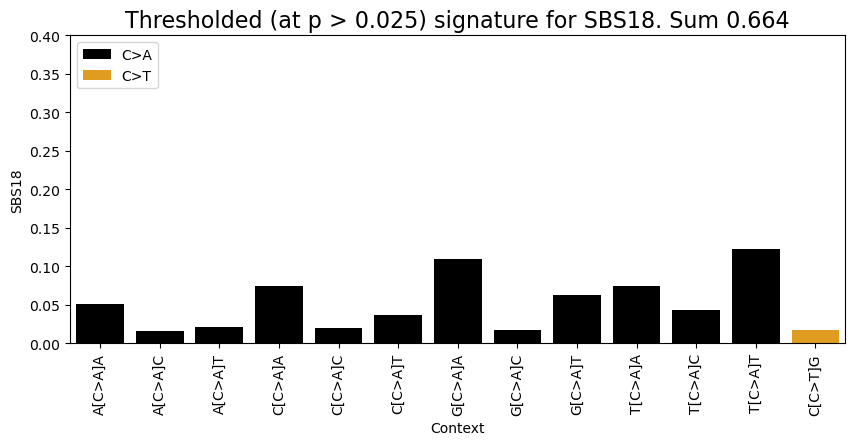

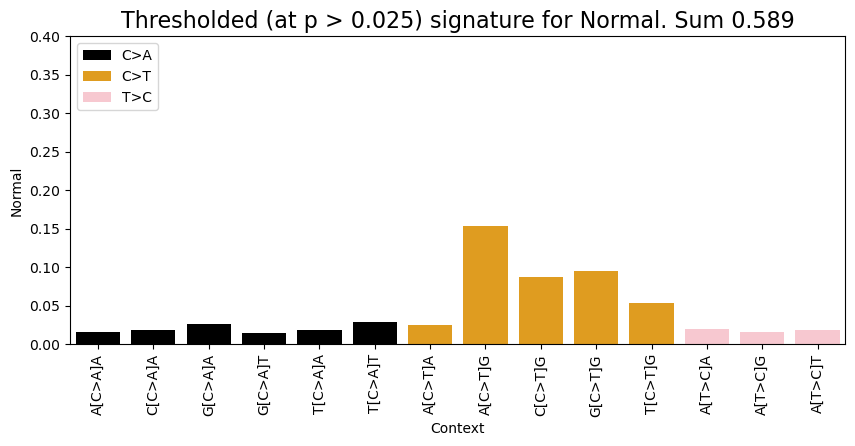

In [7]:
# Keep colours consistent across plots
# Only 6 possible changes so just hard coded it.
sbs_palette = {
    "T>A": "blue",
    "T>C": "red",
    "T>G": "green",
    "C>T": "orange",
    "T>C": "pink",
    "C>A": "black"
}

sig_cols = [col for col in clean_sig_df.columns if ('SBS' in col) or ("Normal" in col)]
for sig_col in sig_cols:
    # Extract, threshold, plot.
    sbs_i = clean_sig_df[["Context", sig_col, "Mutation"]]
    sbs_i_thr = threshold(sbs_i, alpha = 0.015)
    sum_p = np.sum(sbs_i_thr[sig_col])

    fig, ax = plt.subplots(figsize = (10, 4))
    sns.barplot(data = sbs_i_thr, x = "Context", y = sig_col, 
                hue = "Mutation", palette = sbs_palette)
    ax.tick_params(axis = "x", rotation = 90)
    ax.set_ylim(0, 0.4)

    plt.title(f'Thresholded (at p > 0.025) signature for {sig_col}. Sum {round(sum_p, 3)}', fontsize = 16)
    plt.legend(loc = "upper left")
    plt.show()

---
---
---

First classifier: a non-negative least squares to investigate how high the injection level needs to be.

Idea: if $V \approx Wh$, where 
1. $V$ is the known signature (or synthetically created), 
1. $W$ is the weight matrix (we'll use a weight of 0.4/0.4/0.2 as per Xell's email for SBS1, SBS5, and SBS18 for "Normal Colon", and vary the injection level of SBS88),
1. and we can recover $h$ using non-negative least squares (NNLS). Non-negative because people can't have negative signature information.

SciPy has a NNLS method.



In [8]:
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A


In [9]:
m = 96 # Contexts.
n = 4 # SBS1, 5, 18, 88.

W = np.zeros((m, n))

sigs = ["SBS1", "SBS5", "SBS18", "SBS88"]
for j, sig in enumerate(sigs):
    W[:, j] = clean_sig_df[sig]

W[0:3]

array([[8.76022860e-04, 1.19976005e-02, 5.15338577e-02, 1.00000000e-18],
       [2.22011958e-03, 9.43811238e-03, 1.58103874e-02, 1.00000000e-18],
       [1.79727206e-04, 1.84963007e-03, 2.43159756e-03, 1.00000000e-18]])

In [10]:
n_muts_median = 2000
# Is this too high?


def sample_mutational_signature(df, distrib, a=1, k=10**6):
    '''
    Args:
        df: Dataframe with the data 
        distrib: Target distribution to sample from (apart from the Normal-colon distribution)
        a: Weight of the target distribution (1-a will be the weight of the Normal-colon distribution)
        k: Number of samples
    '''
    final_distrib = a*df[distrib] + (1-a)*df["Normal"]
    samples = random.choices(range(96), final_distrib, k=k)
    counts_scaled = np.bincount(samples, minlength=96)/len(samples)
    return counts_scaled

def simulate_lognormal(df, distrib, mean_a, n_trials=200, n_mutations=5000):
    '''
    Log-normal parameterised so the median equals mean_a.
    sigma fixed at 0.3 (moderate right skew).
    '''
    sigma = 0.3
    mu = np.log(mean_a)
    
    results = []
    for _ in range(n_trials):
        a = np.random.lognormal(mu, sigma)
        a = np.clip(a, 0, 1)
        spectrum = sample_mutational_signature(df, distrib, a, k=n_mutations)
        results.append(spectrum)
    return np.array(results)

def simulate_gaussian(df, distrib, mean_a, n_trials=200, n_mutations=5000):
    '''
    mean_a: target proportion of SSBS
    std fixed at 0.1 of mean (same as paper)
    '''
    results=[]
    for __ in range(n_trials):
        a=np.random.normal(loc=mean_a, scale=0.1*mean_a)
        a=np.clip(a,0,1)
        spectrum=sample_mutational_signature(df, distrib, a, k=n_mutations)
        results.append(spectrum)
    return np.array(results) # shape (n_trials,96)

def expected_spectrum(dist_name, mean_a, df, distrib='SBS88',
                      n_samples=200, n_mutations=None):
    '''
    Simulate n_samples spectra from the given distribution at mean_a,then return their average as the expected spectrum E[P(alpha)].

    This is what the model predicts the average tumour spectrum looks like if the population-level colibactin exposure has mean = mean_a and
    follows distribution dist_name.

    Args:
        dist_name : 'Gaussian', 'Beta', or 'LogNormal'
        mean_a: candidate mean alpha (colibactin fraction) in [0, 1]
        df: final_df
        distrib: target signature column
        n_samples: number of spectra to average over (more = smoother loss)
        n_mutations : mutations per spectrum (defaults to TCGA median)

    Returns a 96-element array.
    '''
    if n_mutations is None:
        n_mutations = n_muts_median

    sim_fns = {
        'Gaussian':simulate_gaussian,
        #'Beta': simulate_beta,
        #'LogNormal': simulate_lognormal,
    }

    if dist_name not in sim_fns:
        raise ValueError(f"dist_name must be one of {list(sim_fns.keys())}")

    spectra = sim_fns[dist_name](df, distrib, mean_a,
                                 n_trials=n_samples, n_mutations=n_mutations)
    return spectra.mean(axis=0)  # average across all simulated tumours

print('expected_spectrum defined.')

expected_spectrum defined.


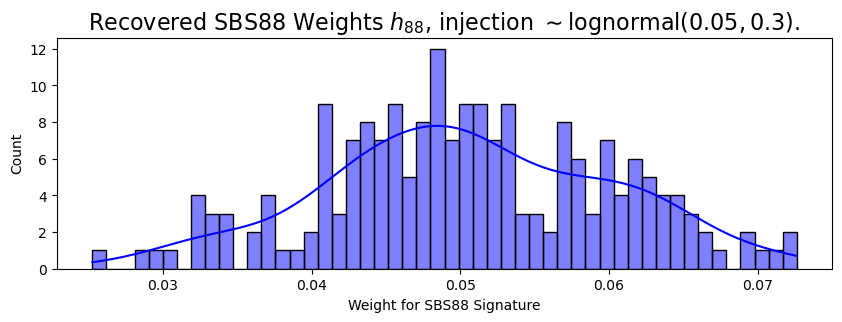

In [11]:
n_trials = 200
# Generate 200 synthetic mutational signatures for mean injection level of 5%.
# NOTE This used to be lognormal, hence the name.
logn_results  = simulate_gaussian(clean_sig_df, "SBS88", mean_a = 0.05, 
                                    n_trials = n_trials)

# Will store all of the recovered weight info here
# 200 x 4, i.e. 200 trials for the four SBS1, 5, 18, 88.
hs = np.zeros((n_trials, n))

for j in range(n_trials):
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.nnls.html
    h = nnls(W, logn_results[j])[0] # Also returns the 2-norm of residual.
    hs[j] = h

# Rough plot to see what the weights for SBS88 are, 
sbs88_weights = hs[:, 3]
fig, ax = plt.subplots(figsize = (10, 3))
sns.histplot(sbs88_weights, bins = 50, kde = True, color = 'blue', alpha = 0.5, ax = ax)
ax.set_xlabel("Weight for SBS88 Signature")
ax.set_title("Recovered SBS88 Weights $h_{88}$, injection $\sim \mathrm{lognormal}(0.05, 0.3)$.", fontsize = 16)
plt.show()

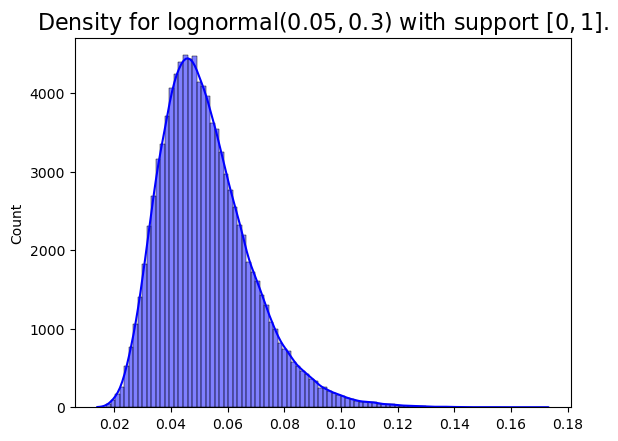

In [12]:
mean_a = 0.05
sigma = 0.3
mu = np.log(mean_a)

N_dist_test = 100000
xs = np.zeros(N_dist_test)

for j in range(N_dist_test):
    x = np.random.lognormal(mu, sigma)
    xs[j] = x 

fig, ax = plt.subplots()
sns.histplot(xs, bins = 100, kde = True, color = 'blue', alpha = 0.5, ax = ax)
ax.set_title("Density for lognormal$(0.05, 0.3)$ with support $[0, 1]$.", fontsize = 16)
plt.show()


### More on NNLS later.

---
---
---

### Approximate Bayesian Computing (ABC)
The idea is something like this.
1. Obtain signature data (could be observed, could be synthetic).
1. Simulate $n = K$ distributions for an injection level $\alpha$ drawn from a normal distribution centred at $a = 0$. This uses Adele's function `simulate_gaussian()`. 
1. For each $j = 1, 2, \dots, K$ of the simulated distributions, find the cosine similarity (or KL divergence) between the simulated distribution and the observed distribution, i.e. $\cos(sim_j, ~actual)$. Threshold this metric to either "accept" or "reject" that the distributions are similar. For cosine, we threshold at $tol = 0.005$ (this looked a good number after doing a small number of experiments).
1. Repeat for all ranges of $a \in [0, 1]$. Here we'll assume a uniform distribution on $a$.
1. Look at the number of accepted distributions for each $a$ to derive some form of posterior distribution.

In [13]:
# SciPy has a built in KL Divergence
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html
import scipy.spatial.distance as scipy_dist
cos_sim = scipy_dist.cosine
KLDiv = stats.entropy

distrib = "SBS88"

def ABC(df, obs_sig, a_range, sig_interest = "SBS88", 
        f_comparison = cos_sim, K = 1000, tol = 0.005):
    ''' 

    '''

    # Store accept (1) and reject (0) for each a,
    # e.g. 3x100 matrix if K = 100.
    accepts = np.zeros((len(a_range), K))

    for i, a in enumerate(a_range):
        # For each a, run K simulations.
        for j in range(K):
            # Compare the two differences and obtain metric.
            simulated_sig = simulate_gaussian(mean_a = a, df = df, 
                                           distrib = sig_interest, n_trials = 1)[0]
        
            difference_score = f_comparison(obs_sig, simulated_sig)
            if (difference_score < tol):
                accepts[i, j] = 1

    # End loop
    sum_accepts = np.sum(accepts, axis = 1)
    normalised_post = sum_accepts / np.sum(sum_accepts)
    return normalised_post

# ================
a_bins = 50
a_range_1 = np.linspace(0, 1, a_bins)
posterior_a = ABC(clean_sig_df, logn_results[0], a_range = a_range_1)

0.33664068036853295


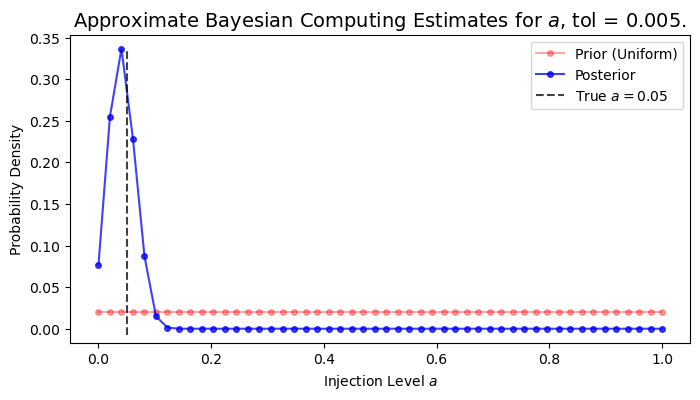

In [14]:
fig, ax = plt.subplots(figsize = (8, 4))
print(np.max(posterior_a))
ax.plot(a_range_1, 1/a_bins * np.ones_like(a_range_1), marker = 'o', markersize = 4, color = 'red', alpha = 0.35, label = "Prior (Uniform)")
ax.plot(a_range_1, posterior_a, marker = 'o', markersize = 4, color = 'blue', alpha = 0.75, label = "Posterior")
ax.axvline(x = 0.05, color = "black", linestyle = "dashed", alpha = 0.75, label = "True $a = 0.05$", ymin = 0.025, ymax = 0.95)

ax.set_xlabel("Injection Level $a$")
ax.set_ylabel("Probability Density")
ax.set_title("Approximate Bayesian Computing Estimates for $a$, tol = 0.005.", fontsize = 14)

plt.legend(loc = "upper right")
plt.show()

In [15]:
# If tolerance is too high - will not give good results.
posterior_b = ABC(clean_sig_df, logn_results[0], a_range = a_range_1, tol = 0.1)

0.05884083553986467


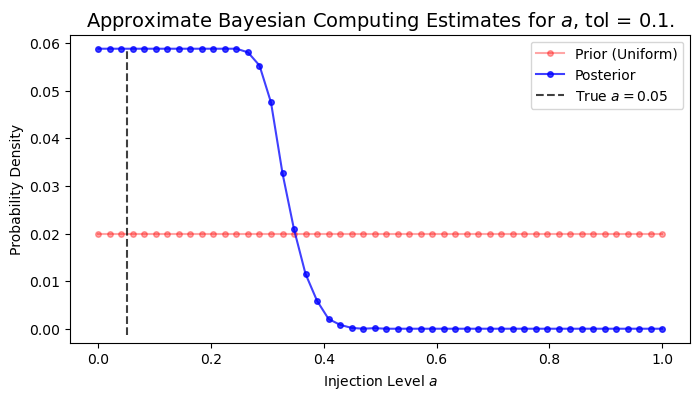

In [16]:
fig, ax = plt.subplots(figsize = (8, 4))
print(np.max(posterior_b))
ax.plot(a_range_1, 1/a_bins * np.ones_like(a_range_1), marker = 'o', markersize = 4, color = 'red', alpha = 0.35, label = "Prior (Uniform)")
ax.plot(a_range_1, posterior_b, marker = 'o', markersize = 4, color = 'blue', alpha = 0.75, label = "Posterior")
ax.axvline(x = 0.05, color = "black", linestyle = "dashed", alpha = 0.75, label = "True $a = 0.05$", ymin = 0.025, ymax = 0.95)

ax.set_xlabel("Injection Level $a$")
ax.set_ylabel("Probability Density")
ax.set_title("Approximate Bayesian Computing Estimates for $a$, tol = 0.1.", fontsize = 14)

plt.legend(loc = "upper right")
plt.show()

In [18]:
def plot_abc(xs, prior, posterior, true_a = None, tol = None):
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.plot(xs, prior, marker = 'x', markersize = 4, color = 'red', alpha = 0.35, label = "Prior")
    ax.plot(a_range_1, posterior, marker = 'o', markersize = 4, color = 'blue', alpha = 0.75, label = "Posterior")
    if (true_a is not None):
        ax.axvline(x = true_a, color = "black", linestyle = "dashed", alpha = 0.75, label = f'True $a = {true_a}$', ymin = 0.025, ymax = 0.95)

    ax.set_xlabel("Injection Level $a$")
    ax.set_ylabel("Probability Density")
    title = "Approximate Bayesian Computing Estimates for $a$"
    if (tol):
        title += f', tol = {tol}.'

    ax.set_title(title, fontsize = 14)

    plt.legend(loc = "upper right")
    plt.show()

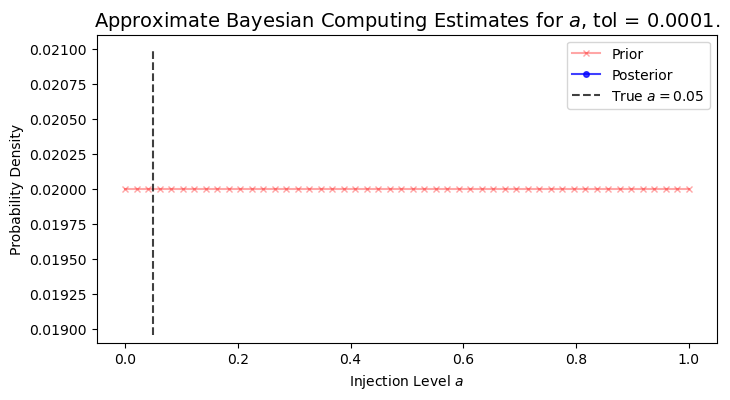

In [19]:
plot_abc(a_range_1, 1/a_bins * np.ones_like(a_range_1), posterior_c, true_a = 0.05, tol = 0.0001)

---
#### Testing again for a synthetic signature created with $a = 0$.

In [20]:
logn_results_zero  = simulate_gaussian(clean_sig_df, "SBS88", mean_a = 0, 
                                    n_trials = n_trials)
posterior_b = ABC(clean_sig_df, logn_results_zero[23], a_range = a_range_1)

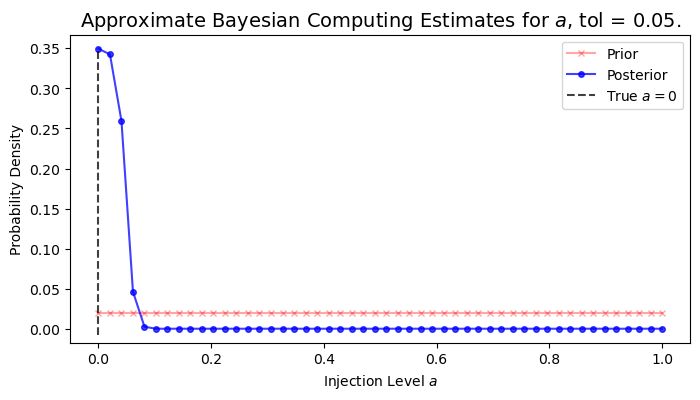

In [21]:
plot_abc(a_range_1, 1/a_bins * np.ones_like(a_range_1), posterior_b, true_a = int(0), tol = 0.05)

In [27]:
logn_results_mid  = simulate_gaussian(clean_sig_df, "SBS88", mean_a = 0.75, 
                                    n_trials = n_trials)

posterior_mid_a = ABC(clean_sig_df, logn_results_mid[47], a_range = a_range_1, tol = 0.01)

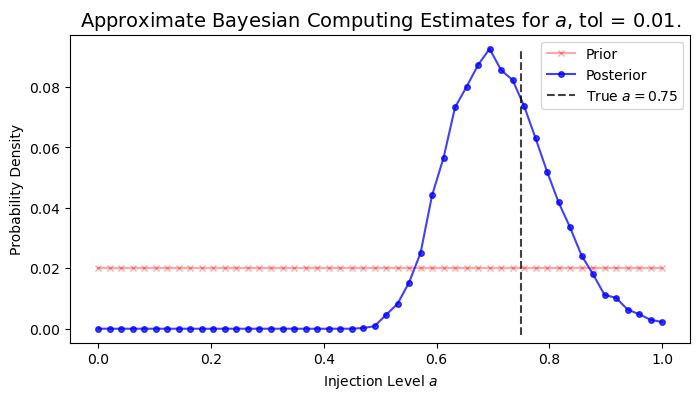

In [28]:
plot_abc(a_range_1, 1/a_bins * np.ones_like(a_range_1), posterior_mid_a, true_a = 0.75, tol = 0.01)